In [15]:
import sys
from pathlib import Path
import importlib
import pandas as pd
ROOT = Path.cwd().parent
sys.path.append(str(ROOT))
from Utility import IdSep
from Utility import Plot
from Utility import Pretraitement
import matplotlib.pyplot as plt

In [3]:
data_path = ROOT / "data" / "EOLENS_2_6.csv"
df = pd.read_csv(data_path)

# Plot composante classique

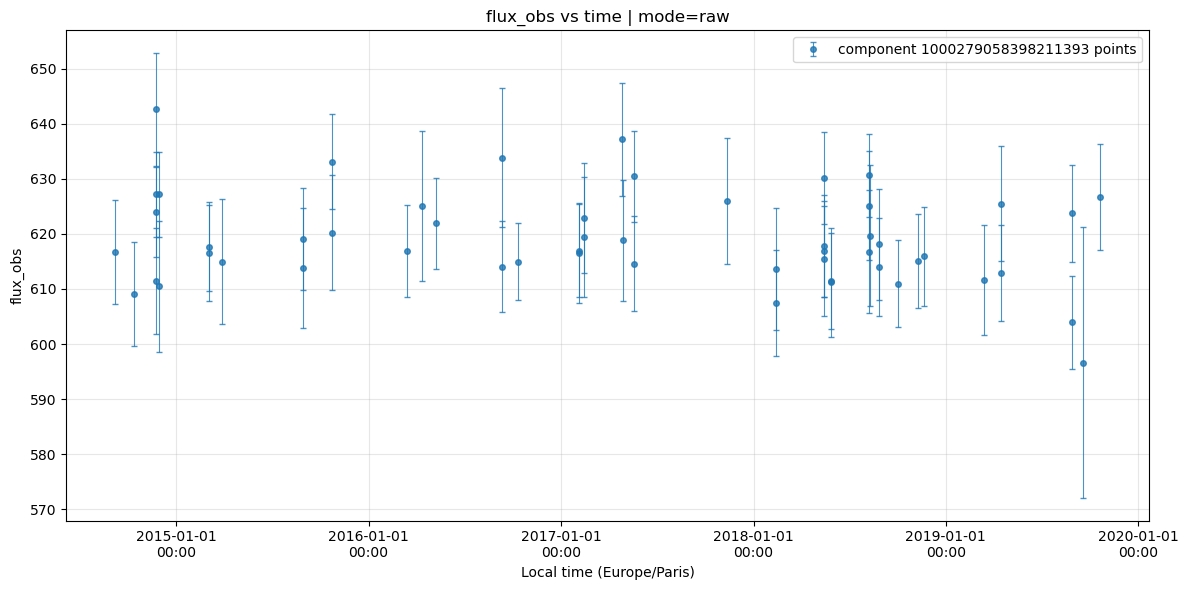

In [4]:
components = Plot.list_lens_components(data_path)
components[:10]
fig, ax = Plot.plot_lens_components_matplotlib(
    data_path,
    lens_component_ids=components[0],
    y_col="flux_obs",
    yerr_col="flux_obs_error",
    y_mode="raw",
    show_points=True,
    show_smooth=False,
    show_gp=False,
)

plt.show()

# Plot composante + Time Delay

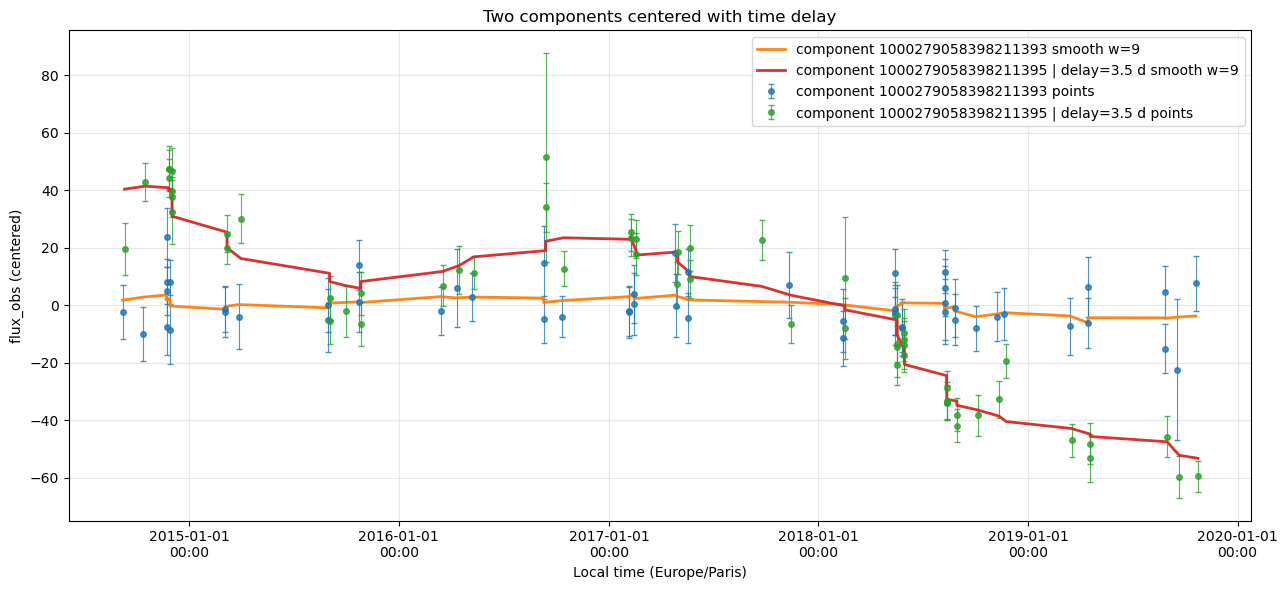

In [5]:
id1 = components[0]
id2 = components[1]

fig, ax = Plot.plot_lens_components_matplotlib(
    data_path,
    lens_component_ids=[id1, id2],
    y_col="flux_obs",
    yerr_col="flux_obs_error",

    y_mode="centered",

    show_points=True,
    show_smooth=True,
    show_gp=False,

    smooth_window=9,

    time_delay_by_component={
        str(id1): 0.0,
        str(id2): 3.5,   # delay in days
    },

    figsize=(13, 6),
    title="Two components centered with time delay",
)

plt.show()

# Plot avec Gaussian Process

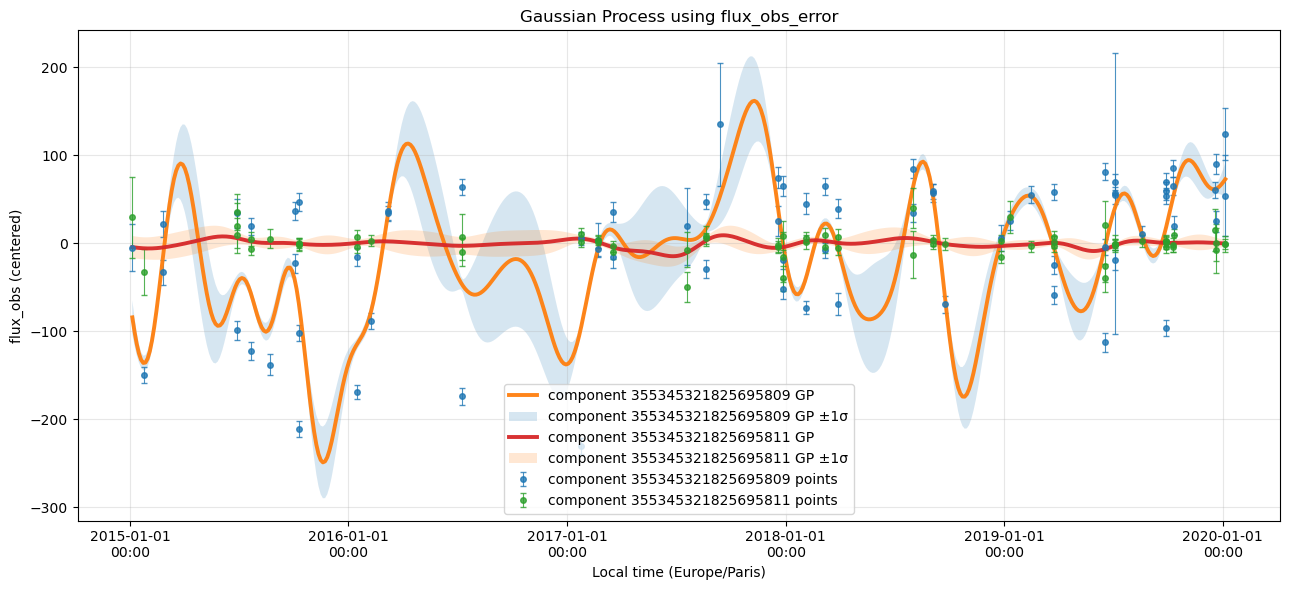

In [9]:
fig, ax = Plot.plot_lens_components_gp(
    data_path,
    lens_component_ids=[355345321825695809, 355345321825695811],

    y_col="flux_obs",
    yerr_col="flux_obs_error",
    y_mode="centered",

    time_delay_by_component={
        str(id1): 0.0,
        str(id2): 3.5,
    },

    gp_length_scale_days=40.0,
    gp_error_scale=1,
    gp_show_uncertainty=True,
    gp_fixed_kernel=True,

    figsize=(13, 6),
    title="Gaussian Process using flux_obs_error",
)

plt.show()

In [16]:
clean_df, source_report, removed_points_df = Pretraitement.preprocess_lightcurves(
    df,

    # Colonnes
    time_col=None,
    y_col="flux_obs",
    yerr_col="flux_obs_error",
    source_col="source_id",
    component_col="lensComponentSourceId",

    # Test sur les premières sources
    max_sources=2000,
    source_selection="first",

    # Agrégation bi-daily
    do_bi_daily=True,
    bin_days=2.0,
    error_mode="mean",

    # SNR / Noise Signal Ratio
    do_snr_filter=True,
    snr_signal_mode="amplitude",
    min_snr=2.0,
    max_noise_signal_ratio=None,
    remove_if_snr_nan=True,

    # DRW compatibility filter
    do_drw_filter=True,
    drw_M=100,
    drw_tau_min=30.0,
    drw_tau_max=1000.0,
    drw_amp_min_factor=0.2,
    drw_amp_max_factor=3.0,
    drw_model_floor=None,

    # Important pour la vitesse
    drw_draw_random=False,

    drw_max_iter=20,
    drw_weight_threshold=0.25,
    drw_max_bad_fraction=0.35,
    drw_min_mean_weight=0.45,

    # 3 sigma après DRW
    do_sigma_clip=True,
    poly_degree=2,
    sigma_clip=3.0,

    # Minimum de points après preprocessing
    min_points_after=20,

    # Plots
    show_removed_plots=True,
    verbose=True,
)

display(source_report)
display(removed_points_df)
display(clean_df)

TypeError: preprocess_lightcurves() got an unexpected keyword argument 'do_drw_filter'. Did you mean 'do_snr_filter'?